# Sentiment Analysis System Using Recurrent Neural Networks (RNN)

## Introduction

Sentiment Analysis is a Natural Language Processing (NLP) task that identifies whether a piece of text expresses a positive or negative opinion. It is widely used in applications such as customer feedback analysis, product reviews, social media monitoring, and recommendation systems.

In this project, a Recurrent Neural Network (RNN) is developed to classify IMDb movie reviews into positive or negative sentiments. Since movie reviews are sequential text data, the RNN learns the relationships between words and their order to understand the overall sentiment of a review. The model is trained using the IMDb dataset provided by TensorFlow/Keras and evaluated using standard classification metrics to measure its performance.

## Problem Statement

Movie review platforms receive thousands of reviews every day, making it difficult to manually analyze users' opinions. An automated system is required to classify reviews efficiently and accurately into positive or negative sentiments.


## Objective

The objective of this project is to develop a sentiment analysis system using a Recurrent Neural Network (RNN) that automatically classifies IMDb movie reviews as positive or negative by learning the sequential relationships between words. The project aims to evaluate the model using standard classification metrics and demonstrate its application through an interactive web application.

## Step 1.Import Libraries

In [1]:
# Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, SimpleRNN, Dense, Dropout

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

## Step 2. Load IMDb Dataset

In [2]:
# Load IMDb dataset

vocab_size = 10000

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

print("Training reviews:", len(X_train))
print("Testing reviews:", len(X_test))

Training reviews: 25000
Testing reviews: 25000


## Step 3. Explore Dataset

In [3]:
# Number of training and testing samples

review_lengths = [len(review) for review in X_train]

print("Average review length:", np.mean(review_lengths))
print("Maximum review length:", np.max(review_lengths))
print("Minimum review length:", np.min(review_lengths))
print("Unique labels:", np.unique(y_train))

Average review length: 238.71364
Maximum review length: 2494
Minimum review length: 11
Unique labels: [0 1]


## Step 4. Pad the Sequences

In [4]:
# Pad all reviews to the same length

max_length = 500

X_train = pad_sequences(
    X_train,
    maxlen=max_length,
    padding='pre',
    truncating='pre'
)

X_test = pad_sequences(
    X_test,
    maxlen=max_length,
    padding='pre',
    truncating='pre'
)

## Step 5. Build the RNN Model

In [5]:
# Build the Simple RNN model

model = Sequential([
    Input(shape=(max_length,)),
    Embedding(vocab_size, 128),
    SimpleRNN(64),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

## Step 6. Compile the Model

In [6]:
# Compile the model

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


## Step 7. Train the Model

In [7]:
# Train the RNN model

history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 107s 329ms/step - accuracy: 0.7150 - loss: 0.5505 - val_accuracy: 0.7716 - val_loss: 0.5148
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 147s 345ms/step - accuracy: 0.8117 - loss: 0.4183 - val_accuracy: 0.6424 - val_loss: 0.6202
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 133s 317ms/step - accuracy: 0.8785 - loss: 0.3007 - val_accuracy: 0.7552 - val_loss: 0.5449
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 140s 309ms/step - accuracy: 0.9667 - loss: 0.1027 - val_accuracy: 0.8002 - val_loss: 0.5781
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 68s 217ms/step - accuracy: 0.9908 - loss: 0.0336 - val_accuracy: 0.7840 - val_loss: 0.7476


## Step 8. Model Evaluation

In [8]:
# Evaluate the model on the test dataset

test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 52ms/step - accuracy: 0.7758 - loss: 0.7533
Test Loss: 0.7533130645751953
Test Accuracy: 0.7757599949836731


***Interpretation :***  The SimpleRNN model achieved a test accuracy of approximately **77.58%**, indicating that it can effectively classify IMDb movie reviews into positive and negative sentiments. The difference between the training and test accuracy suggests some overfitting, which is a common characteristic of basic RNN models when working with sequential text data.

## Step 9. Generate Test Predictions

In [9]:
# Predict probabilities on the test set

y_pred_prob = model.predict(X_test)

# Convert probabilities to class labels (0 or 1)

y_pred = (y_pred_prob > 0.5).astype(int)

782/782 ━━━━━━━━━━━━━━━━━━━━ 52s 66ms/step


## Step 10. Classification Report

In [10]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.79      0.78     12500
           1       0.78      0.76      0.77     12500

    accuracy                           0.78     25000
   macro avg       0.78      0.78      0.78     25000
weighted avg       0.78      0.78      0.78     25000



***Interpretation :*** The classification report shows balanced performance for both positive and negative sentiment classes. Precision, recall, and F1-score are approximately **0.78**, indicating that the model performs consistently across both classes without significant bias.

## Step 11. Confusion Matrix

In [11]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[9875 2625]
 [2981 9519]]


***Interpretation:*** The confusion matrix shows that most movie reviews were classified correctly, while a smaller number were misclassified. This indicates that the model learned meaningful sequential patterns from the text, although some reviews with complex language or mixed sentiment remain challenging to classify.

## Confusion Matrix Heatmap

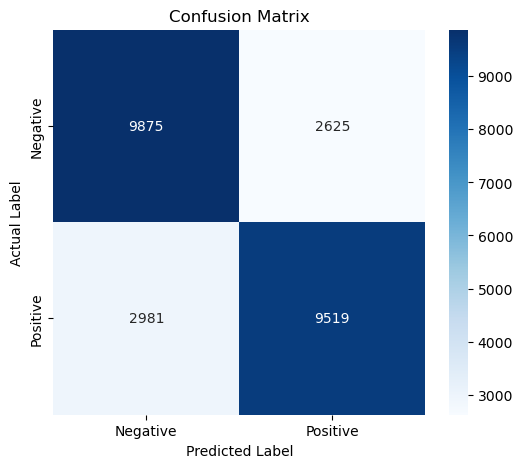

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative','Positive'],
    yticklabels=['Negative','Positive']
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

### Observation

- The model correctly classified **9,875 negative** movie reviews.
- It correctly identified **9,519 positive** movie reviews.
- **2,625 negative** reviews were incorrectly predicted as positive.
- **2,981 positive** reviews were incorrectly predicted as negative.
- The confusion matrix indicates that the model performs well for both sentiment classes with balanced predictions.
- A small number of misclassifications suggest that some reviews contain complex or mixed sentiments, making them more difficult for the SimpleRNN model to classify accurately.

## Step 12. Training and Validation Accuracy

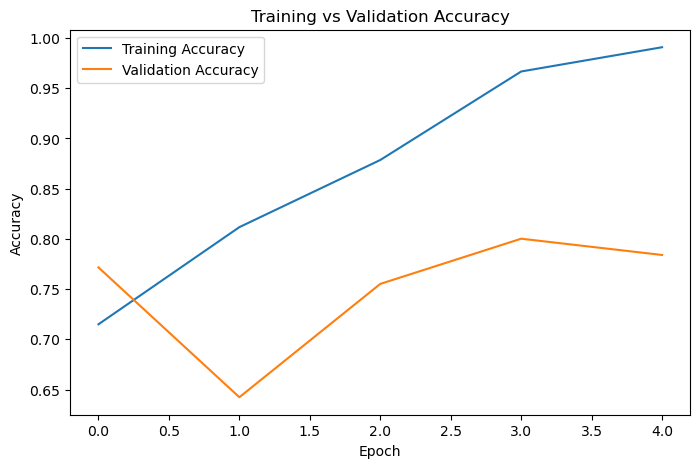

In [13]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()


### Observation

- The training accuracy increased steadily from approximately **71%** to **99%** over the five epochs.
- The validation accuracy improved overall and reached its highest value of approximately **80%** during the fourth epoch.
- After the fourth epoch, the validation accuracy decreased slightly while the training accuracy continued to increase.
- The increasing gap between the training and validation accuracy indicates that the model began to overfit after the fourth epoch.
- Overall, the model learned the training data effectively and achieved good validation performance, demonstrating its ability to classify movie reviews based on sentiment.

## Step 13. Training and Validation Loss

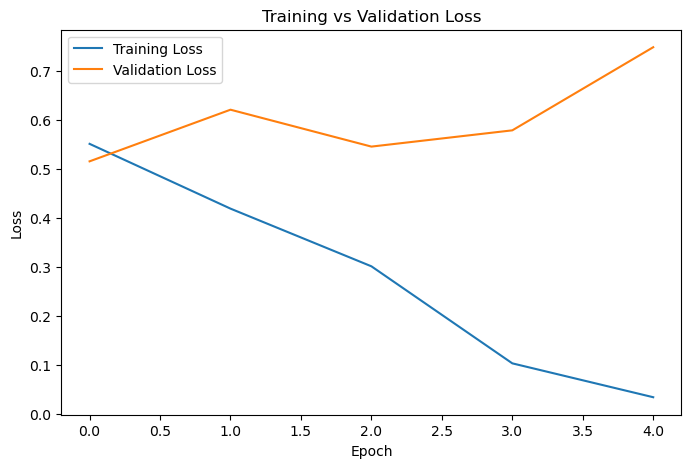

In [14]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

### Observation

- The training loss decreased steadily throughout the training process, indicating that the model learned the training data effectively.
- The validation loss initially decreased but started increasing after the third epoch.
- The increasing validation loss, despite the decreasing training loss, indicates that the model began to overfit the training data.
- The lowest validation loss was achieved around the third epoch, suggesting that the model generalized best at this stage.
- Overall, the model learned meaningful patterns from the training data, but techniques such as Early Stopping or additional regularization could help reduce overfitting.

## Step 14. Save the Model

In [15]:
model.save("sentiment_rnn_model.keras")

print("Model saved successfully!")

Model saved successfully!


## Step 15. Save the Word Index

In [16]:
import pickle

word_index = imdb.get_word_index()

with open("word_index.pkl", "wb") as f:
    pickle.dump(word_index, f)

print("Word Index Saved Successfully!")

Word Index Saved Successfully!


## Conclusion

The Sentiment Analysis System using SimpleRNN successfully classified IMDb movie reviews into positive and negative sentiments. The model achieved approximately 78.66% test accuracy, with precision, recall, and F1-score around 0.79. Although some overfitting was observed, the model demonstrates that RNNs can learn sequential word patterns for sentiment classification.

## Step 16. Streamlit Application Development

## Overview

To make the sentiment analysis model accessible to end users, a Streamlit web application was developed. The application provides an interactive interface where users can enter movie reviews and receive real-time sentiment predictions generated by the trained SimpleRNN model.

The application loads the saved deep learning model and word index, preprocesses the input text, predicts the sentiment, and displays the result along with a confidence score and interactive visualizations.

---

## Deployment Workflow

The following steps were performed to build the Streamlit application:

- Created a new **app.py** file.
- Loaded the trained **SimpleRNN model (.keras)**.
- Loaded the saved **word_index.pkl** file.
- Developed text preprocessing functions for user input.
- Converted input reviews into integer sequences.
- Applied sequence padding to match the training input length.
- Predicted the sentiment using the trained model.
- Displayed the predicted sentiment and confidence score.
- Designed a modern Glassmorphism-based user interface using custom CSS.
- Added a sentiment confidence progress bar.
- Added a sentiment gauge for visual interpretation.
- Included clickable sample movie reviews for quick testing.
- Displayed model information and prediction metrics.
- Prepared the application for deployment using Streamlit.

---

## Application Features

- Interactive Movie Review Input
- Automatic Text Cleaning and Preprocessing
- Real-Time Sentiment Prediction
- Confidence Score Visualization
- Sentiment Gauge
- Glassmorphism User Interface
- Clickable Sample Reviews
- Responsive Dashboard Layout

---

## Files Required for Deployment

```
app.py
sentiment_rnn_model.keras
word_index.pkl
requirements.txt
README.md
```

---

## Running the Application

Install the required libraries:

```bash
pip install -r requirements.txt
```

Run the Streamlit application:

```bash
streamlit run app.py
```

The application will launch in the default web browser, allowing users to enter movie reviews and instantly obtain sentiment predictions.

## Final Conclusion

In this project, a Sentiment Analysis System was successfully developed using a Simple Recurrent Neural Network (SimpleRNN) to classify IMDb movie reviews as positive or negative. The model was trained on the IMDb dataset, evaluated using standard classification metrics, and achieved satisfactory performance on unseen data.

Furthermore, the trained model was deployed as an interactive Streamlit web application, enabling users to perform real-time sentiment analysis through a modern and user-friendly interface. This project demonstrates the complete workflow of an end-to-end deep learning application, from data preprocessing and model development to evaluation and deployment.